# Demo: Annotating Downsampled Li2023b Dataset with Pretrained EpiAgent-B

This notebook demonstrates the process of annotating a downsampled Li2023b dataset using the pretrained EpiAgent-B model. 
The following resources are required:
- EpiAgent-B model (`EpiAgent-B.pth`)
- Cell type file for EpiAgent-B (`EpiAgent-B_cell_types.json`)
- Downsampled Li2023b dataset (`Li2023b_downsampled_10000_cells.h5ad`)

Please ensure these files are downloaded from: https://drive.google.com/drive/folders/1WlNykSCNtZGsUp2oG0dw3cDdVKYDR-iX?usp=sharing


# Step 1: Data Preprocessing - TFIDF and Tokenization

In this step, we preprocess the input dataset by applying TFIDF to transform discrete count data into continuous values. 
The importance of each accessible cCRE in each cell is quantified. Subsequently, tokenization is performed to generate 
cell sentences, stored in `adata.obs`.

# Test Cell: Weights & Biases Setup

This cell tests the Weights & Biases (wandb) connection before running the main experiment. 
Run this cell to verify your wandb setup is working correctly.


In [1]:
import wandb

# Test wandb connection
print("Testing Weights & Biases setup...")
test_run = wandb.init(project="epiagent-test", name="wandb-test", mode="online")
wandb.log({"test_metric": 1.0})
print("✓ Weights & Biases is working correctly!")
wandb.finish()
print("Test complete. You can proceed with the main experiment.")


Testing Weights & Biases setup...


wandb: Currently logged in as: jack-naimer (jack-naimer-epfl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ Weights & Biases is working correctly!


test_metric,▁
test_metric,1


Test complete. You can proceed with the main experiment.


In [2]:
import scanpy as sc
import numpy as np
from epiagent.tokenization import tokenization
from epiagent.preprocessing import global_TFIDF, global_TFIDF_with_shuffling, global_TFIDF_with_complete_shuffling

# Load the AnnData object
input_path = '../data/sample/raw_h5ad/Li2023b_downsampled_10000_cells.h5ad'
adata = sc.read_h5ad(input_path)

# Load the cCRE document frequency and compute TF-IDF
cCRE_document_frequency = np.load('../data/cCRE_document_frequency.npy')
adata = global_TFIDF(adata, cCRE_document_frequency)
adata_shuffled = global_TFIDF_with_shuffling(adata, cCRE_document_frequency)
adata_complete_shuffled = global_TFIDF_with_complete_shuffling(adata, cCRE_document_frequency)

# Tokenize the data using the tokenization function
tokenization(adata)
tokenization(adata_shuffled)
tokenization(adata_complete_shuffled)

print("Data preprocessing completed: TFIDF applied, and cell sentences generated.")

Shuffling rows: 100%|██████████| 9999/9999 [03:52<00:00, 43.10it/s]


Tokenization complete: 'cell_sentences' column added to adata.obs.
Tokenization complete: 'cell_sentences' column added to adata.obs.
Tokenization complete: 'cell_sentences' column added to adata.obs.
Data preprocessing completed: TFIDF applied, and cell sentences generated.


# Step 2: Create Dataset and DataLoader for EpiAgent-B

Here, we construct a PyTorch dataset and dataloader from the processed AnnData object. Each dataset element 
represents a cell sentence, with special tokens ([CLS] and [SEP]) appended. Accessible cCREs are sampled if their 
indices exceed the maximum length.

In [3]:
from epiagent.dataset import CellDataset, collate_fn
from torch.utils.data import DataLoader

# Create dataset
cell_sentences = adata.obs['cell_sentences'].tolist()
cell_sentences_shuffled = adata_shuffled.obs['cell_sentences'].tolist()
cell_sentences_complete_shuffled = adata_complete_shuffled.obs['cell_sentences'].tolist()
dataset = CellDataset(cell_sentences=cell_sentences, max_length=8192)
dataset_shuffled = CellDataset(cell_sentences=cell_sentences_shuffled, max_length=8192)
dataset_complete_shuffled = CellDataset(cell_sentences=cell_sentences_complete_shuffled, max_length=8192)

# Create dataloader
dataloader = DataLoader(dataset, batch_size=10, shuffle=False, num_workers=4, collate_fn=collate_fn)
dataloader_shuffled = DataLoader(dataset_shuffled, batch_size=10, shuffle=False, num_workers=4, collate_fn=collate_fn)
dataloader_complete_shuffled = DataLoader(dataset_complete_shuffled, batch_size=10, shuffle=False, num_workers=4, collate_fn=collate_fn)
print("Dataset and DataLoader successfully created.")

Dataset and DataLoader successfully created.


# Step 3: Load Pretrained EpiAgent-B Model

In this step, we load the pretrained EpiAgent-B model and its associated cell types.

In [4]:
import torch
import json
from sklearn.preprocessing import LabelEncoder
from epiagent.model import EpiAgent_supervised

# Load cell types for EpiAgent-NT
cell_type_file = '../model/EpiAgent-B/EpiAgent-B_cell_types.json'
with open(cell_type_file, 'r') as f:
    cell_types_for_epiant_b = json.load(f)

label_encoder = LabelEncoder()
label_encoder.fit(cell_types_for_epiant_b)

# Load pretrained model
model_path = '../model/EpiAgent-B/EpiAgent-B.pth'
epiagent_b = EpiAgent_supervised(
    vocab_size=1355449, num_layers=18, embedding_dim=512, num_attention_heads=8, 
    max_rank_embeddings=8192, num_classes=len(cell_types_for_epiant_b), use_flash_attn=True
)
epiagent_b.load_state_dict(torch.load(model_path))

print("Pretrained EpiAgent-NT model loaded successfully.")

/home/naimer/miniforge3/envs/EpiAgentBench/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pretrained EpiAgent-NT model loaded successfully.


# Step 4: Inference with EpiAgent-B

Perform inference using the pretrained EpiAgent-B model to obtain predicted cell types and cell embeddings. 
This step also filters out rare predicted cell types.

In [5]:
from epiagent.inference import infer_cell_types, filter_rare_cell_types

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
epiagent_b.to(device)

# Perform inference
results = infer_cell_types(model=epiagent_b, device=device, dataloader=dataloader, need_cell_embeddings=True)
results_shuffled = infer_cell_types(model=epiagent_b, device=device, dataloader=dataloader_shuffled, need_cell_embeddings=True)
results_complete_shuffled = infer_cell_types(model=epiagent_b, device=device, dataloader=dataloader_complete_shuffled, need_cell_embeddings=True)

# Filter rare predicted cell types
predicted_labels_filtered = filter_rare_cell_types(
    results['predicted_labels'], np.array(results['predicted_probabilities']), threshold=0.005
)

predicted_labels_filtered_shuffled = filter_rare_cell_types(
    results_shuffled['predicted_labels'], np.array(results_shuffled['predicted_probabilities']), threshold=0.005
)

predicted_labels_filtered_complete_shuffled = filter_rare_cell_types(
    results_complete_shuffled['predicted_labels'], np.array(results_complete_shuffled['predicted_probabilities']), threshold=0.005
)

# Map predicted labels to real cell types
predicted_cell_types = label_encoder.inverse_transform(predicted_labels_filtered)
predicted_cell_types_shuffled = label_encoder.inverse_transform(predicted_labels_filtered_shuffled)
predicted_cell_types_complete_shuffled = label_encoder.inverse_transform(predicted_labels_filtered_complete_shuffled)

print("Inference completed: Predicted cell types and embeddings generated.")

Inference completed: Predicted cell types and embeddings generated.


# Step 5: Validation and Visualization

Validate the predictions by visualizing the predicted cell types and comparing them with true cell types using UMAP. 
Additionally, generate a confusion matrix to quantify the performance of the model.

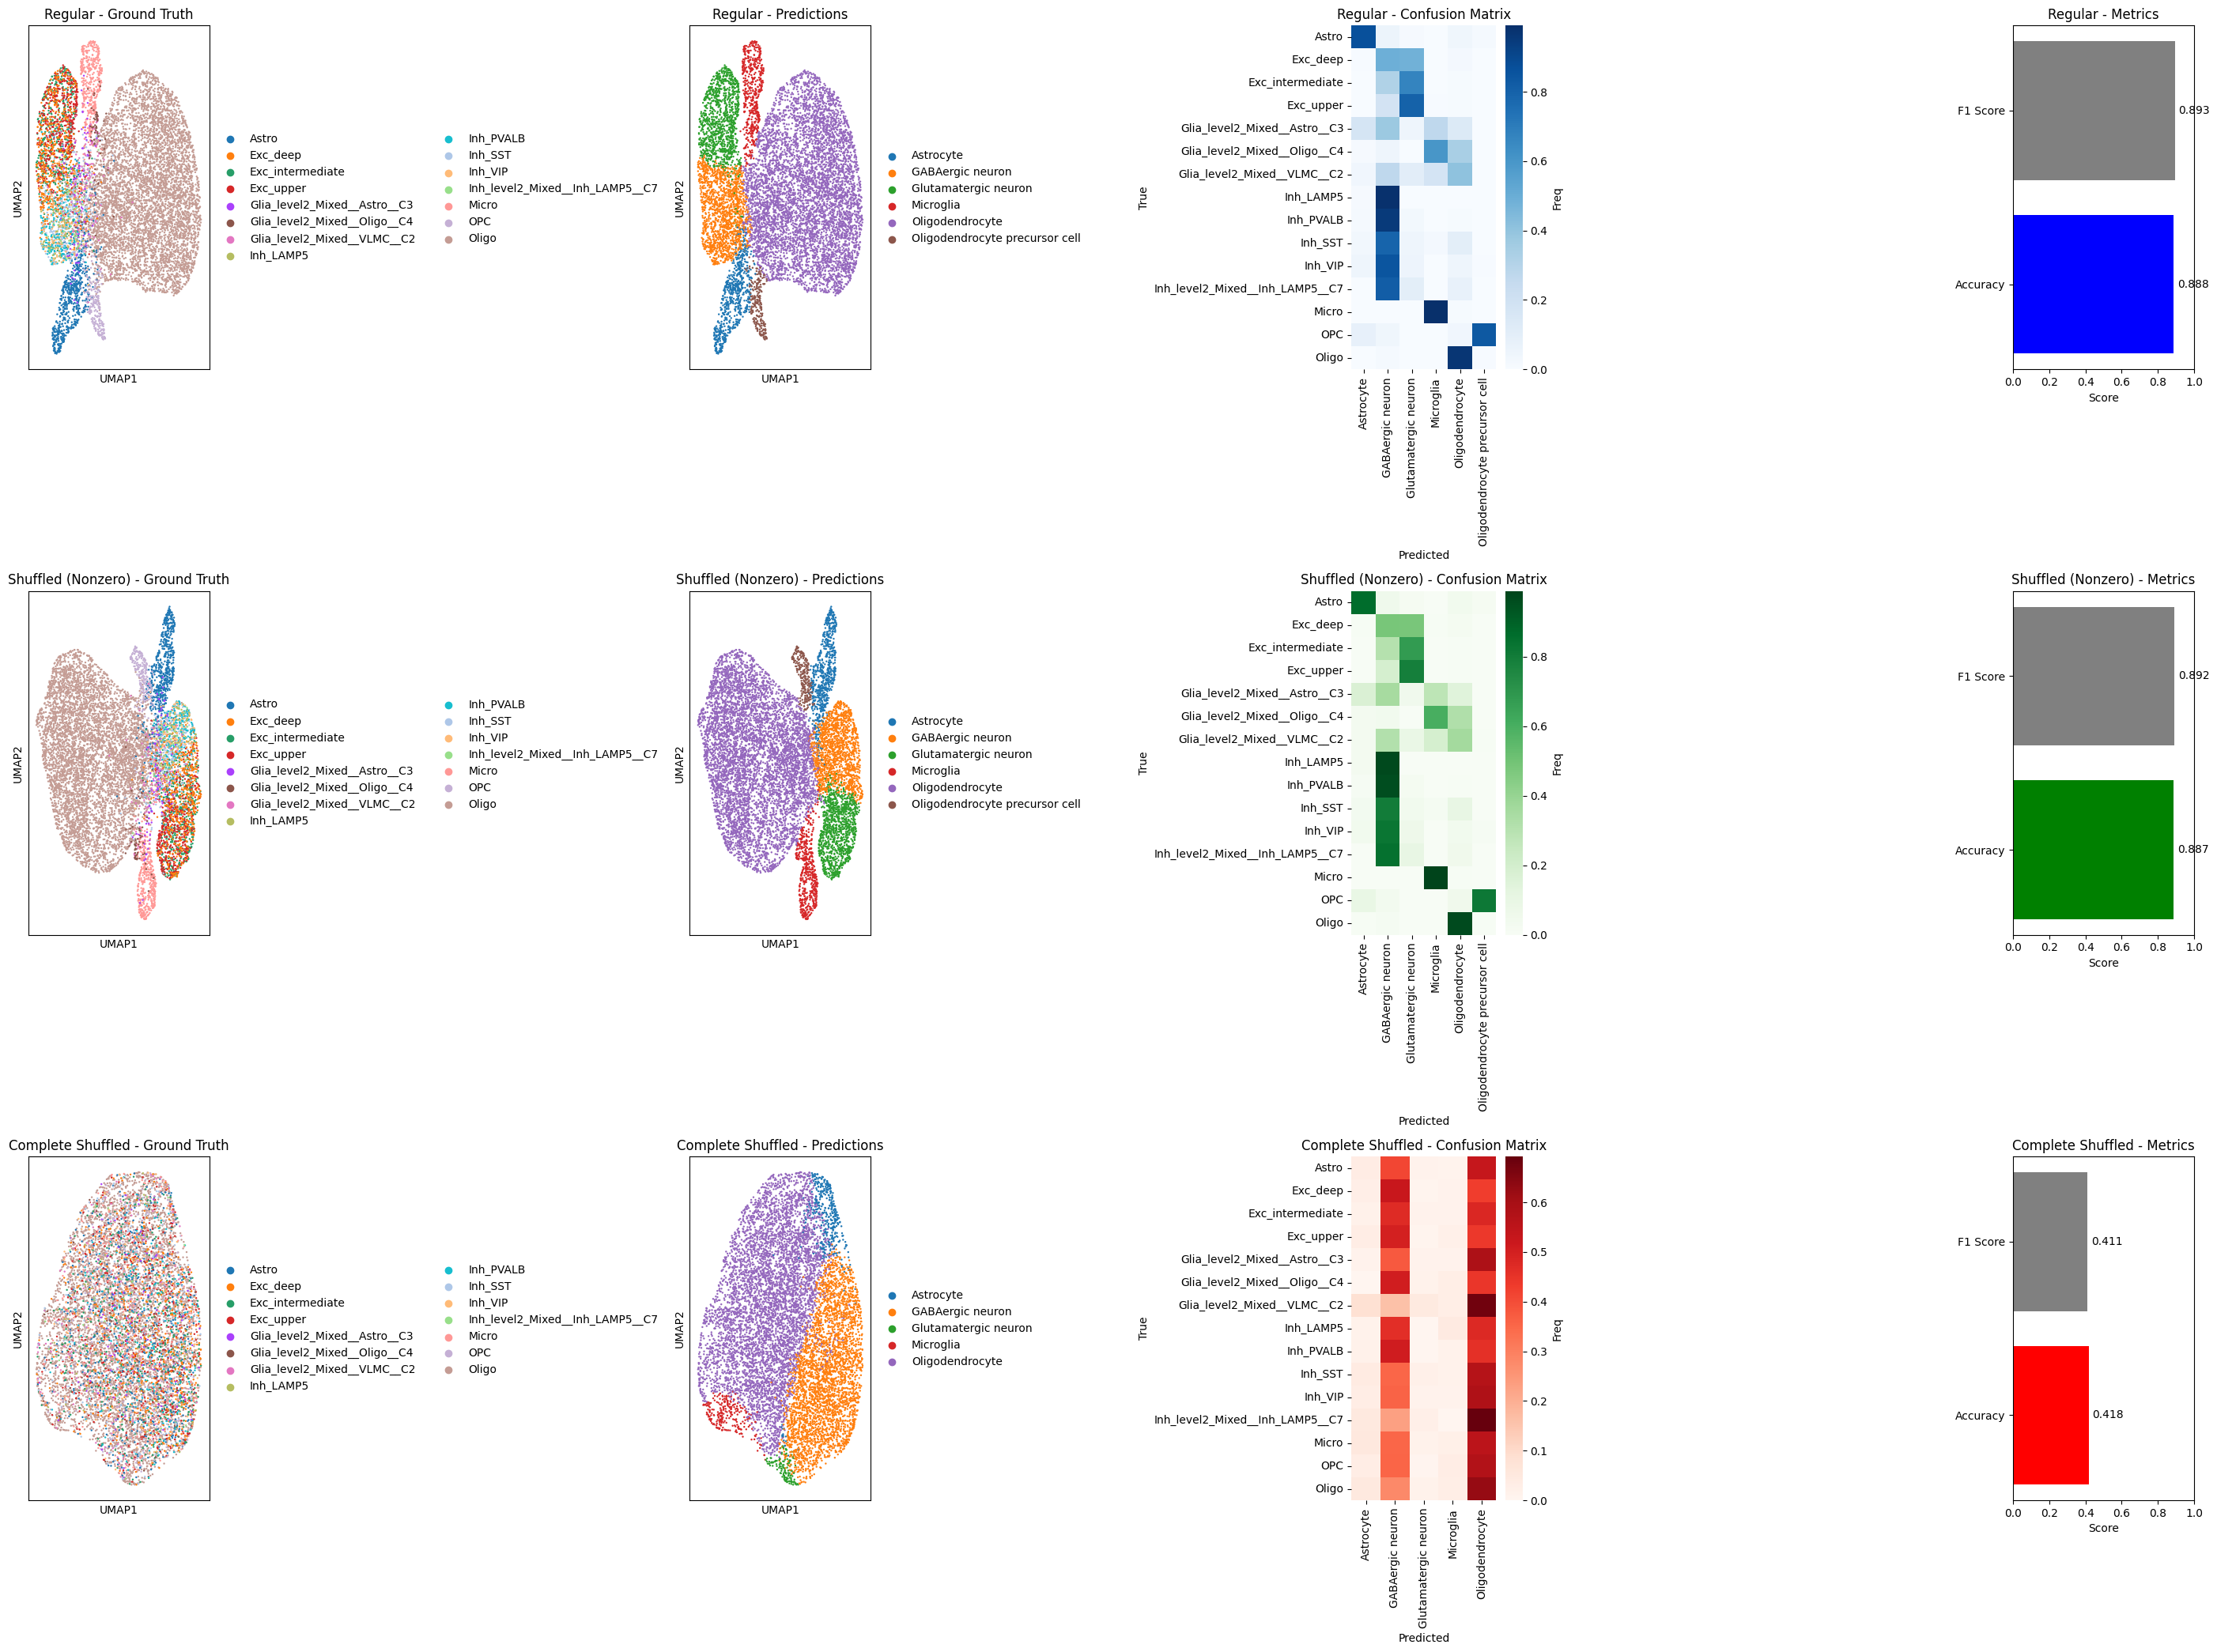

Regular: Acc=0.888, F1=0.893
Shuffled: Acc=0.887, F1=0.892
Complete: Acc=0.418, F1=0.411


complete_accuracy,▁
complete_f1,▁
regular_accuracy,▁
regular_f1,▁
shuffled_accuracy,▁
shuffled_f1,▁
complete_accuracy,0.41848
complete_f1,0.411
regular_accuracy,0.88824
regular_f1,0.89334
shuffled_accuracy,0.88722


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb
from sklearn.metrics import accuracy_score, f1_score

# Ground truth mapping
GT_MAP = {'Astro': 'Astrocyte', 'Exc_deep': 'Glutamatergic neuron', 'Exc_intermediate': 'Glutamatergic neuron',
          'Exc_upper': 'Glutamatergic neuron', 'Glia_level2_Mixed__Astro__C3': 'Astrocyte',
          'Glia_level2_Mixed__Oligo__C4': 'Oligodendrocyte', 'Glia_level2_Mixed__VLMC__C2': None,
          'Inh_LAMP5': 'GABAergic neuron', 'Inh_PVALB': 'GABAergic neuron', 'Inh_SST': 'GABAergic neuron',
          'Inh_VIP': 'GABAergic neuron', 'Inh_level2_Mixed__Inh_LAMP5__C7': 'GABAergic neuron',
          'Micro': 'Microglia', 'OPC': 'Oligodendrocyte precursor cell', 'Oligo': 'Oligodendrocyte'}

# Initialize W&B
wandb.init(project="epiagent-annotation", name="EpiAgent-B-comparison")

# Helper function to compute metrics
def compute_metrics(adata_obj, pred_col, pred_results):
    adata_obj.obs[pred_col] = label_encoder.inverse_transform(
        filter_rare_cell_types(pred_results['predicted_labels'], 
                              np.array(pred_results['predicted_probabilities']), threshold=0.005))
    adata_obj.obsm[f'emb_{pred_col}'] = pred_results['cell_embeddings']
    sc.pp.neighbors(adata_obj, use_rep=f'emb_{pred_col}')
    sc.tl.umap(adata_obj)
    
    # Confusion matrix
    true_l = adata_obj.obs['cell_type']
    pred_l = adata_obj.obs[pred_col]
    true_classes = sorted(true_l.unique())
    pred_classes = sorted(pred_l.unique())
    conf_mat = pd.DataFrame(0, index=true_classes, columns=pred_classes)
    for t, p in zip(true_l, pred_l):
        conf_mat.loc[t, p] += 1
    norm_conf = conf_mat.div(conf_mat.sum(axis=1), axis=0)
    
    # Ground truth-based metrics
    mask = true_l != 'Glia_level2_Mixed__VLMC__C2'
    true_mapped = true_l[mask].map(GT_MAP)
    pred_filt = pred_l[mask]
    acc = accuracy_score(true_mapped, pred_filt)
    f1 = f1_score(true_mapped, pred_filt, average='weighted', zero_division=0)
    
    return norm_conf, acc, f1, true_classes, pred_classes

# Compute for all three methods
from epiagent.inference import infer_cell_types, filter_rare_cell_types

metrics = {}
metrics['Regular'] = compute_metrics(adata, 'pred_reg', results)
metrics['Shuffled'] = compute_metrics(adata_shuffled, 'pred_shuf', results_shuffled)
metrics['Complete'] = compute_metrics(adata_complete_shuffled, 'pred_comp', results_complete_shuffled)

# Create 3x4 visualization
fig, axes = plt.subplots(3, 4, figsize=(28, 21))

datasets = [
    (adata, 'pred_reg', 'cell_type', 'Regular', 'Blues', metrics['Regular']),
    (adata_shuffled, 'pred_shuf', 'cell_type', 'Shuffled (Nonzero)', 'Greens', metrics['Shuffled']),
    (adata_complete_shuffled, 'pred_comp', 'cell_type', 'Complete Shuffled', 'Reds', metrics['Complete'])
]

for i, (data, pred_col, true_col, label, cmap, (conf, acc, f1, tc, pc)) in enumerate(datasets):
    # Col 1: UMAP - Ground Truth
    sc.pl.umap(data, color=true_col, ax=axes[i,0], show=False, title=f'{label} - Ground Truth')
    # Col 2: UMAP - Predictions
    sc.pl.umap(data, color=pred_col, ax=axes[i,1], show=False, title=f'{label} - Predictions')
    # Col 3: Confusion Matrix
    sns.heatmap(conf, annot=False, cmap=cmap, ax=axes[i,2], cbar_kws={'label': 'Freq'}, 
                xticklabels=pc, yticklabels=tc)
    axes[i,2].set_title(f'{label} - Confusion Matrix')
    axes[i,2].set_xlabel('Predicted')
    axes[i,2].set_ylabel('True')
    # Col 4: Metrics Bar Plot
    axes[i,3].barh(['Accuracy', 'F1 Score'], [acc, f1], color=[cmap.lower().replace('s',''), 'gray'])
    axes[i,3].set_xlim(0, 1)
    axes[i,3].set_title(f'{label} - Metrics')
    axes[i,3].set_xlabel('Score')
    for j, (metric, val) in enumerate(zip(['Accuracy', 'F1 Score'], [acc, f1])):
        axes[i,3].text(val + 0.02, j, f'{val:.3f}', va='center')

plt.tight_layout()
plt.savefig("comprehensive_3x4_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({
    "comprehensive_3x4_plot": wandb.Image("comprehensive_3x4_comparison.png"),
    "regular_accuracy": metrics['Regular'][1],
    "regular_f1": metrics['Regular'][2],
    "shuffled_accuracy": metrics['Shuffled'][1],
    "shuffled_f1": metrics['Shuffled'][2],
    "complete_accuracy": metrics['Complete'][1],
    "complete_f1": metrics['Complete'][2]
})

print(f"Regular: Acc={metrics['Regular'][1]:.3f}, F1={metrics['Regular'][2]:.3f}")
print(f"Shuffled: Acc={metrics['Shuffled'][1]:.3f}, F1={metrics['Shuffled'][2]:.3f}")
print(f"Complete: Acc={metrics['Complete'][1]:.3f}, F1={metrics['Complete'][2]:.3f}")

wandb.finish()

In [7]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns
# import wandb
# from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# # Initialize Weights & Biases
# wandb.init(
#     project="epiagent-annotation",
#     name="EpiAgent-B-Li2023b-downsampled",
#     config={
#         "model": "EpiAgent-B",
#         "dataset": "Li2023b_downsampled_10000_cells",
#         "vocab_size": 1355449,
#         "num_layers": 18,
#         "embedding_dim": 512,
#         "num_attention_heads": 8,
#         "max_rank_embeddings": 8192,
#         "max_length": 8192,
#         "batch_size": 5,
#         "threshold": 0.005
#     }
# )

# # Assign predictions to AnnData
# adata.obs['predicted_cell_types'] = predicted_cell_types
# adata.obsm['cell_embeddings_from_EpiAgent-B'] = results['cell_embeddings']

# # UMAP visualization
# sc.pp.neighbors(adata, use_rep='cell_embeddings_from_EpiAgent-B')
# sc.tl.umap(adata)
# sc.pl.umap(adata, color=['cell_type'], save="umap_true_cell_types.png")
# sc.pl.umap(adata, color=['predicted_cell_types'], save="umap_predicted_cell_types.png")

# # Prepare labels for confusion matrix visualization
# true_labels = adata.obs['cell_type']
# predicted_labels = adata.obs['predicted_cell_types']
# true_class_list = sorted(true_labels.unique())
# pred_class_list = sorted(predicted_labels.unique())

# # Create an empty confusion matrix
# conf_matrix = np.zeros((len(true_class_list), len(pred_class_list)), dtype=int)

# # Map class names to indices
# true_class_to_index = {cls: idx for idx, cls in enumerate(true_class_list)}
# pred_class_to_index = {cls: idx for idx, cls in enumerate(pred_class_list)}

# # Populate the confusion matrix
# for pred, true in zip(predicted_labels, true_labels):
#     pred_idx = pred_class_to_index[pred]
#     true_idx = true_class_to_index[true]
#     conf_matrix[true_idx, pred_idx] += 1

# # Convert to DataFrame for better readability
# conf_matrix_df = pd.DataFrame(conf_matrix, index=true_class_list, columns=pred_class_list)

# # Print the confusion matrix values
# print("\n" + "="*80)
# print("CONFUSION MATRIX (Raw Counts)")
# print("="*80)
# print(conf_matrix_df.to_string())
# print("\n")

# # Normalize the confusion matrix
# normalized_conf_matrix = conf_matrix_df.div(conf_matrix_df.sum(axis=1), axis=0)

# # Print the normalized confusion matrix
# print("="*80)
# print("NORMALIZED CONFUSION MATRIX")
# print("="*80)
# print(normalized_conf_matrix.to_string())
# print("\n")

# # Calculate metrics
# accuracy = accuracy_score(true_labels, predicted_labels)
# precision, recall, f1, support = precision_recall_fscore_support(
#     true_labels, predicted_labels, average='weighted', zero_division=0
# )
# macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
#     true_labels, predicted_labels, average='macro', zero_division=0
# )

# # Print metrics
# print("="*80)
# print("CLASSIFICATION METRICS")
# print("="*80)
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Weighted Precision: {precision:.4f}")
# print(f"Weighted Recall: {recall:.4f}")
# print(f"Weighted F1-Score: {f1:.4f}")
# print(f"Macro Precision: {macro_precision:.4f}")
# print(f"Macro Recall: {macro_recall:.4f}")
# print(f"Macro F1-Score: {macro_f1:.4f}")
# print("\n")

# # Print detailed classification report
# print("="*80)
# print("DETAILED CLASSIFICATION REPORT")
# print("="*80)
# print(classification_report(true_labels, predicted_labels, zero_division=0))

# # Visualize the confusion matrix
# plt.figure(figsize=(0.3 * len(pred_class_list), 0.5 * len(true_class_list)))
# sns.heatmap(normalized_conf_matrix, annot=False, fmt=".2f", xticklabels=pred_class_list, yticklabels=true_class_list, cmap="Blues")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Normalized Confusion Matrix")
# plt.tight_layout()
# plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
# plt.show()

# # Log results to Weights & Biases
# wandb.log({
#     "accuracy": accuracy,
#     "weighted_precision": precision,
#     "weighted_recall": recall,
#     "weighted_f1": f1,
#     "macro_precision": macro_precision,
#     "macro_recall": macro_recall,
#     "macro_f1": macro_f1,
#     "num_true_classes": len(true_class_list),
#     "num_predicted_classes": len(pred_class_list),
#     "total_samples": len(true_labels)
# })

# # Log confusion matrices to wandb
# wandb.log({
#     "confusion_matrix_raw": wandb.Table(dataframe=conf_matrix_df),
#     "confusion_matrix_normalized": wandb.Table(dataframe=normalized_conf_matrix)
# })

# # Log UMAP plots to wandb
# wandb.log({
#     "umap_true_cell_types": wandb.Image("figures/umapumap_true_cell_types.png"),
#     "umap_predicted_cell_types": wandb.Image("figures/umapumap_predicted_cell_types.png"),
#     "confusion_matrix_plot": wandb.Image("confusion_matrix.png")
# })

# # Log detailed per-class metrics
# per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
#     true_labels, predicted_labels, average=None, zero_division=0, labels=true_class_list
# )
# per_class_metrics = pd.DataFrame({
#     'class': true_class_list,
#     'precision': per_class_precision,
#     'recall': per_class_recall,
#     'f1_score': per_class_f1,
#     'support': per_class_support
# })
# wandb.log({"per_class_metrics": wandb.Table(dataframe=per_class_metrics)})

# print("✓ Results logged to Weights & Biases successfully!")
# wandb.finish()

# # # Save processed AnnData
# # output_path = '../data/sample/processed_h5ad/Li2023_downsampled_10000_cells_EpiAgent-B_outputs.h5ad'
# # adata.write(output_path)
# # print(f"Processed AnnData saved at {output_path}")